## Import & Mask Creation

In [1]:
# --- PARAMETER SETTING ---
TP = 300
VIEW = '0'

In [2]:
from pathlib import Path
import napari 
import sys
import tifffile
from lineagetree import LineageTree, read_from_mastodon
import numpy as np
from skimage.measure import regionprops
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interactive
from ipywidgets import Layout
import h5py
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion
from skimage.filters import threshold_otsu, threshold_multiotsu, sobel
from skimage.segmentation import watershed

# CUSTOM FUNCTIONS
from watermasks.utils import paths, import_registration_mats_multiview, registered_position_of_id_in_t, paint_annotations, view_overlays_3d_V2, block_timer
from watermasks.main import percentile_intensities_sampler, draw_sph_at_pos

# --- IMPORT DATA AND FILES ---
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = paths()

# LOAD INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    test_image = f5[f't00{TP}']['s00']['2']['cells'][:]

# LOAD REG. MATRICES AND LINEAGETREE
R_of_t = import_registration_mats_multiview(path_xml, TP-5,TP+5)
lT = read_from_mastodon(path_mast)

shape_full_h5 = np.array([300, 1888, 2100]) # as measured in T7_3 data (dir = H:)
shape_test_image = np.array(np.shape(test_image))
scaling = shape_test_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_test_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS
reg_pos_at_t = []
for mastodon_id_t in lT.time_nodes[TP]:
    x, y, z = registered_position_of_id_in_t(mastodon_id_t, lT, TP, R_of_t, VIEW, scaling)
    reg_pos_at_t.append([x, y, z])
reg_pos_at_t = np.asarray(reg_pos_at_t)

# --- VISUALIZE THE ANNOTATIONS ---
an_space = an_space = paint_annotations(TP, lT, shape_test_image,R_of_t,scaling,VIEW,1)

transformations extracted for all views from xml


c:\Users\Tassos\miniconda3\envs\watersh\lib\site-packages\lineagetree\_io\_loaders.py:895: UserWarning: The provided `time` dictionary had keys that were not nodes. They have been removed
  return LineageTree(


full image shape = [ 300 1888 2100]
2nd h5 layer has shape = [300 472 525] 
-scaling ratio is [z, y, x] = [1.   0.25 0.25]
done painting


In [3]:
# --- IMAGE PRE-PROCESSING ---

# PARAMETERS
EROSION_RADIUS = 7 # after tweaking 

im = test_image
pos_array = np.array([p[::-1] for p in reg_pos_at_t]).round().astype(np.uint16)
im_gauss = gaussian_filter(im, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)

erosion = grey_erosion(im_gauss_median, size=EROSION_RADIUS)
im_for_ws = im_gauss_median - erosion
im_ws_gauss = gaussian_filter(im_for_ws, sigma = 1)

In [4]:
# --- EDITING THE ADAPTIVE MASK LOOP ---

# PARAMETERS
INTENSITY_FLOOR = 10

# CREATE THE FIRST IGNORE MASK
ignore_mask = []
ignore_mask = im_gauss_median < INTENSITY_FLOOR

In [5]:
starting_min_intensity=500 # min intensity value a the beggining of the loop
min_mask_floor_limit=10 # intensity is never accepted bellow this value
percent_of_th=100
min_th_vol=300
max_th_vol=1500
total_steps=10

pos_array = np.array([p[::-1] for p in reg_pos_at_t]).round().astype(np.uint16)
seeds = np.zeros_like(im)
seeds[tuple(pos_array.T)] = np.arange(1, len(reg_pos_at_t) + 1)
all_seeds = set(np.unique(seeds)) - {0}

vols = {}
# Remove bad initialization

def get_mask(current_min_intensity, global_min_intensity_):
    thresh_val = max(current_min_intensity, global_min_intensity_)
    return thresh_val, (im_for_ws > thresh_val) & (~ignore_mask) # returns True at positions where intensity is greater than the threshhold, if pixel should not be ignored according to original ignore_mask.

# FIRST WATERSHED, STARTING WITH 
ws = watershed(np.max(im_ws_gauss) - im_ws_gauss, seeds, mask=get_mask(starting_min_intensity, starting_min_intensity)[1])
print(f"First applied thershold = {starting_min_intensity}")

# FIRST FILTERING
# Yes, it could be part of the main while loop.
unique, counts = np.unique_counts(ws)
vols = dict(zip(unique, counts))
for s, v in vols.items():
    if s != 0 and (v < min_th_vol or v > max_th_vol): # don't check the background
        ws[ws == s] = 0
ws0 = ws.copy()
# Visualize the initial, segmentation, OLNLY FOR TESTING

missed_seeds = all_seeds - set(np.unique(ws))

found_seeds = {}
pct1 = 100
found_seeds[pct1] = len(all_seeds - missed_seeds)
print("- starting missing:", len(missed_seeds))

inc = 1 # for visualization reasons
intensities_samples = percentile_intensities_sampler(im_ws_gauss, intensity_thresh_range=[min_mask_floor_limit, starting_min_intensity], print_thresholds=True)
for pct, current_threshold in intensities_samples.items():
    with block_timer(): # Toggle it if you want to time each interation
        if not missed_seeds:
            break
        
        current_thresh, mask = get_mask(current_threshold, min_mask_floor_limit) #  Lowest intensity is dectated by the intensities partitions
        new_ws = watershed(np.max(im_for_ws) - im_for_ws, seeds, mask=mask)
        print(f"*Applied thershold = {current_threshold} @ {pct}%")

        unique, counts = np.unique_counts(new_ws)
        vols = dict(zip(unique, counts))

        for s in missed_seeds.intersection(vols.keys()):
            if s != 0 and min_th_vol < vols[s] < max_th_vol:
                # if s == 362:
                #     print(f"!!!! vol[s=362] = {vols[s]}")
                ws[new_ws == s] = s

        if inc == 2:
            ws1 = ws.copy()
            # Visualize the 2nd interation of th segmentation image, OLNY FOR TESTING

        missed1 = len(missed_seeds)
        missed_seeds = all_seeds - set(np.unique(ws))
        missed2 = len(missed_seeds)
        found_seeds[pct] = missed1 - missed2
        print("-- missing:", len(missed_seeds))
        inc+=1

First applied thershold = 500
- starting missing: 274
99.99%      ---->      497.0
99.9%      ---->      474.0
99%      ---->      320.0
97%      ---->      175.0
95%      ---->      122.0
92%      ---->      90.0
90%      ---->      79.0
80%      ---->      51.0
50%      ---->      23.0
30%      ---->      16.0
10%      ---->      12.0
*Applied thershold = 497.0 @ 99.99%
-- missing: 274
-(Time elapsed: 4.067772 s)

*Applied thershold = 474.0 @ 99.9%
-- missing: 259
-(Time elapsed: 4.898111 s)

*Applied thershold = 320.0 @ 99%
-- missing: 124
-(Time elapsed: 11.112837 s)

*Applied thershold = 175.0 @ 97%
-- missing: 43
-(Time elapsed: 7.962650 s)

*Applied thershold = 122.0 @ 95%
-- missing: 34
-(Time elapsed: 4.464970 s)

*Applied thershold = 90.0 @ 92%
-- missing: 20
-(Time elapsed: 4.935215 s)

*Applied thershold = 79.0 @ 90%
-- missing: 18
-(Time elapsed: 4.464790 s)

*Applied thershold = 51.0 @ 80%
-- missing: 17
-(Time elapsed: 5.100893 s)

*Applied thershold = 23.0 @ 50%
-- miss

In [6]:
l_tot=len(lT.time_nodes[TP])
l_missed = len(missed_seeds)
sig=3
print(f'out of {l_tot} annotations, missed {l_missed}({l_missed/l_tot*100:.3g}%)')

out of 399 annotations, missed 16(4.01%)


In [7]:
print(missed_seeds)

{np.int16(256), np.int16(2), np.int16(294), np.int16(296), np.int16(169), np.int16(394), np.int16(236), np.int16(301), np.int16(16), np.int16(145), np.int16(80), np.int16(273), np.int16(338), np.int16(151), np.int16(249), np.int16(254)}


## Adding missed seeds regions: spherical regions

In [ ]:
radius = (3*min_th_vol/(4*np.pi))**(1/3) # the sphere will have the minimum allowed volume
for ms in missed_seeds:
    pos_ms = np.asarray(np.where(seeds == ms)).T.ravel()
    print(pos_ms)
    x, y, z = np.ogrid[:shape_test_image[0], :shape_test_image[1], :shape_test_image[2]]

    ms_mask = (z-pos_ms[2])**2 + (y-pos_ms[1])**2 + (x-pos_ms[0])**2 <= radius**2 

    ws[ms_mask] = ms

[183 349 159]
[193 297  98]
[206 360 201]
[239 262 114]
[194 308 118]
[249 232 116]
[ 40 251 352]
[241 184  99]
[173 360 198]
[ 78 152 404]
[243 269 122]
[173 210  32]
[248 225  99]
[233 178  80]
[253 277 212]
[243 208  91]


In [9]:
viewer = napari.Viewer()
viewer.add_image(test_image)
viewer.add_image(seeds, colormap='green')
viewer.add_labels(ws)
napari.run()

## Discussion

The shperical method is too slow in my implementation ~ 1 sec / missed seed

But the results are decent:

For TP = 500, for 20% missed seeds:

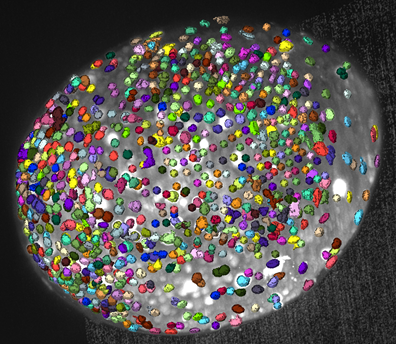 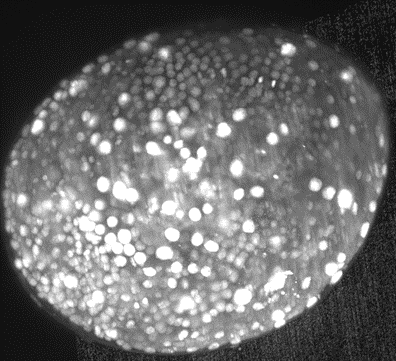

- For TP = 400 (easier):

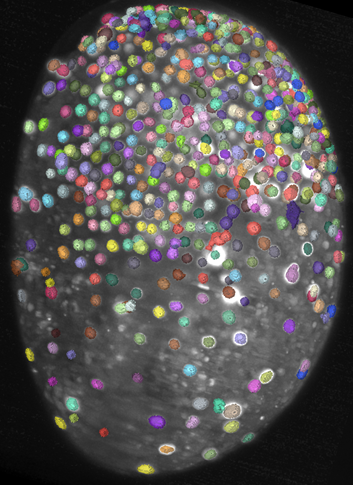
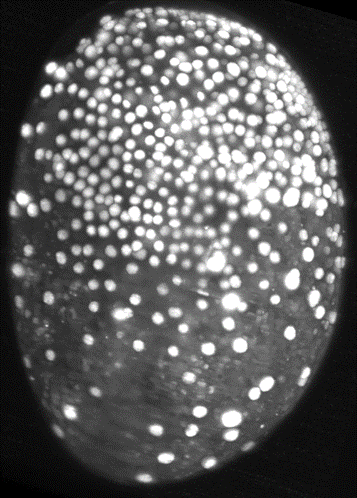

## Short array & mask tutorial

In [10]:
n = 10
rand_mat=np.reshape(range(100),(n,n))
print(rand_mat)

[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]


In [11]:
rand_mat == 45

array([[False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False,  True, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False]])

In [12]:
np.asarray(np.where(rand_mat == 45)).T

array([[4, 5]])

In [13]:
missed_seeds_pos = np.asarray(np.where(rand_mat == 45)).T

In [14]:
shape = (50, 50, 50)
arr = np.zeros(shape)

center = np.array([25, 25, 25])  # (z, y, x)
radius = 5
value = 1.0

In [15]:
z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]

In [16]:
mask = (z - center[0])**2 + (y - center[1])**2 + (x - center[2])**2 <= radius**2

In [17]:
arr[mask] = 1

In [18]:
viewer = napari.Viewer()
viewer.add_image(seeds)
napari.run()